Spin Echo EPI vs Fast Spin Echo
===============================

Introduction
------------

I recently came across an educational article that discusses the following question. Is the "b0" image we typically acquired as part of a diffusion dataset equivalent to a T2WI? In this notebook, we will explore the sense in which the answer to the question above is "yes" using a simulation experiment. Furthermore, we will compare single-shot to multi-shot acquisition and demonstrate the advantages of multi-shot acquisition in terms through a point spread function analysis.

Methods
-------

We first import some necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import peak_widths

We consider a matrix size of 256 along the phase encoding direction with an field of view (FOV) of 128 mm. The echo spacing is set to 12.3 ms. The effective echo time (TE) is calculated accordingly. In addition, we consider a uniform T2 value of 70 ms and T2* value of 50 ms across the entire image. For multi-shot acquisition, we consider 5 shots.

In [2]:
# config
N = 256  # matrix size
FOV = 128  # FOV (mm)
ESP = 12.3e-3  # echo spacing (s)
T2 = 70e-3  # T2 (s)
T2s = 50e-3  # T2* (s)
TE = (N // 2) * ESP  # effective TE (s)
SHOTS = 5  # number of shots for multi-shot
KY = np.arange(-N//2, N//2)
Y = np.arange(-N//2, N//2)

Then, we define two helper functions. The first function computes the segment of k-space acquired in each shot for multi-shot acquisition. The second function simulates the monoexponential decay during readout.

In [3]:
# util
def interleaved_segments(N, shots):
    return [np.arange(start, N, shots) for start in range(shots)]

def simulate_kspace_weight(seq, shots, N, ky, esp, t2, t2s):
    weights = np.zeros(N)
    echo_idx = np.zeros(N)
    for seg in interleaved_segments(N, shots):
        echo_idx[seg] = np.arange(seg.size)
    center_idx = np.where(ky == 0)[0]
    center_echo = echo_idx[center_idx[0]]
    te_lines = (echo_idx - center_echo) * esp
    if seq == 'epi':
        weights = np.exp(-np.abs(te_lines) / t2s)
    elif seq == 'fse':
        weights = np.exp(-np.abs(te_lines) / t2)
    return weights / weights.max()

We then run the simulation script.

In [4]:
# k-space weighting (single-shot = shots=1, multi-shot uses SHOTS)
W_epi = simulate_kspace_weight('epi', 1, N, KY, ESP, T2, T2s)
W_epi_ms = simulate_kspace_weight('epi', SHOTS, N, KY, ESP, T2, T2s)
W_fse = simulate_kspace_weight('fse', 1, N, KY, ESP, T2, T2s)
W_fse_ms = simulate_kspace_weight('fse', SHOTS, N, KY, ESP, T2, T2s)

# psf 
psf_epi = np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(W_epi))))
psf_epi /= psf_epi.max()
psf_fse = np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(W_fse))))
psf_fse /= psf_fse.max()
psf_epi_ms = np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(W_epi_ms))))
psf_epi_ms /= psf_epi_ms.max()
psf_fse_ms = np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(W_fse_ms))))
psf_fse_ms /= psf_fse_ms.max()

Results
-------

For both sequences, we compute the full width at half maximum (FWHM) of the point spread function (PSF) and the effective resolution.

Nominal resolution: 0.50 mm
Effective resolution (SE EPI, single-shot): 9.93 mm
Effective resolution (FSE/TSE, single-shot): 7.13 mm
Effective resolution (SE EPI, 5-shot): 2.00 mm
Effective resolution (FSE/TSE, 5-shot): 1.54 mm


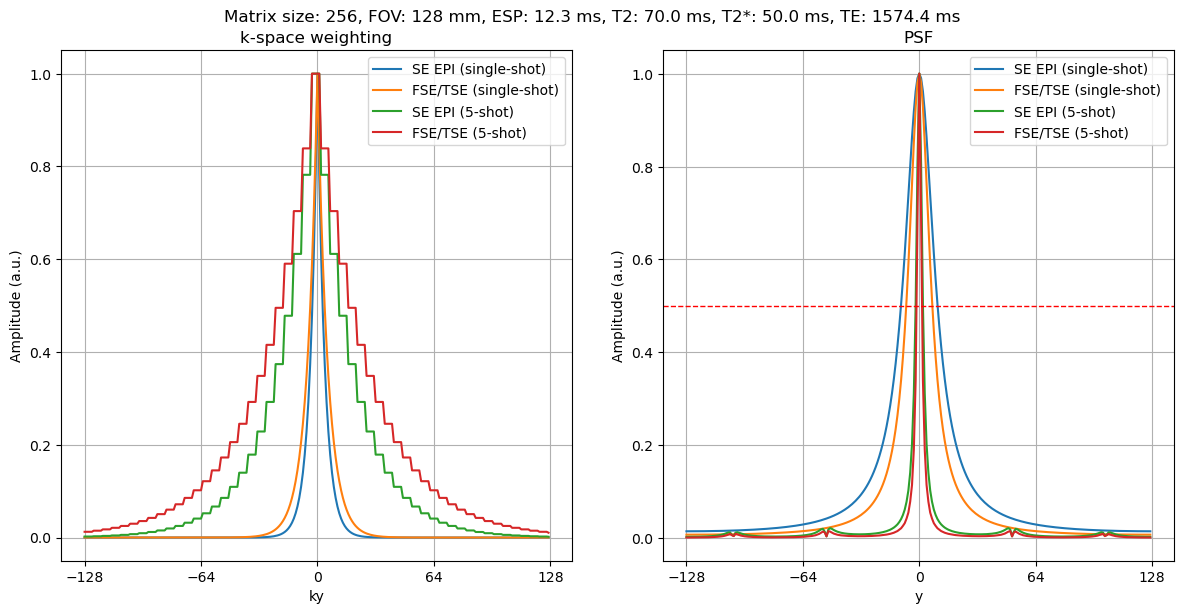

In [5]:
# fwhm
peak = np.array([N // 2])

fwhm_epi, _, _, _ = peak_widths(psf_epi, peak, rel_height=0.5)
res_epi = fwhm_epi[0] * (FOV / N)
fwhm_fse, _, _, _ = peak_widths(psf_fse, peak, rel_height=0.5)
res_fse = fwhm_fse[0] * (FOV / N)
fwhm_epi_ms, _, _, _ = peak_widths(psf_epi_ms, peak, rel_height=0.5)
res_epi_ms = fwhm_epi_ms[0] * (FOV / N)
fwhm_fse_ms, _, _, _ = peak_widths(psf_fse_ms, peak, rel_height=0.5)
res_fse_ms = fwhm_fse_ms[0] * (FOV / N)

print(f'Nominal resolution: {FOV / N:.2f} mm')
print(f'Effective resolution (SE EPI, single-shot): {res_epi:.2f} mm')
print(f'Effective resolution (FSE/TSE, single-shot): {res_fse:.2f} mm')
print(f'Effective resolution (SE EPI, {SHOTS}-shot): {res_epi_ms:.2f} mm')
print(f'Effective resolution (FSE/TSE, {SHOTS}-shot): {res_fse_ms:.2f} mm')

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout='constrained')
axes[0].plot(KY, W_epi, label='SE EPI (single-shot)', color='C0')
axes[0].plot(KY, W_fse, label='FSE/TSE (single-shot)', color='C1')
axes[0].plot(KY, W_epi_ms, label=f'SE EPI ({SHOTS}-shot)', color='C2')
axes[0].plot(KY, W_fse_ms, label=f'FSE/TSE ({SHOTS}-shot)', color='C3')
axes[0].set_title('k-space weighting')
axes[0].set_xlabel('ky')
axes[0].set_ylabel('Amplitude (a.u.)')
axes[0].legend()
axes[0].grid(True)
axes[0].set_xticks(np.arange(-N//2, N//2+1, 64))
axes[0].set_box_aspect(1)
axes[1].plot(Y, psf_epi, label='SE EPI (single-shot)', color='C0')
axes[1].plot(Y, psf_fse, label='FSE/TSE (single-shot)', color='C1')
axes[1].plot(Y, psf_epi_ms, label=f'SE EPI ({SHOTS}-shot)', color='C2')
axes[1].plot(Y, psf_fse_ms, label=f'FSE/TSE ({SHOTS}-shot)', color='C3')
axes[1].axhline(0.5, color='r', linestyle='--', linewidth=1.0)
axes[1].set_title('PSF')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Amplitude (a.u.)')
axes[1].legend()
axes[1].grid(True)
axes[1].set_xticks(np.arange(-N//2, N//2+1, 64))
axes[1].set_box_aspect(1)
fig.suptitle(f'Matrix size: {N}, FOV: {FOV} mm, ESP: {ESP*1e3:.1f} ms, T2: {T2*1e3:.1f} ms, T2*: {T2s*1e3:.1f} ms, TE: {TE*1e3:.1f} ms')
plt.show()
fig.savefig('epi_fse.png', dpi=300)